<a href="https://colab.research.google.com/github/MishterBluesky/BacillusNetwork/blob/main/TS2CG_GUI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

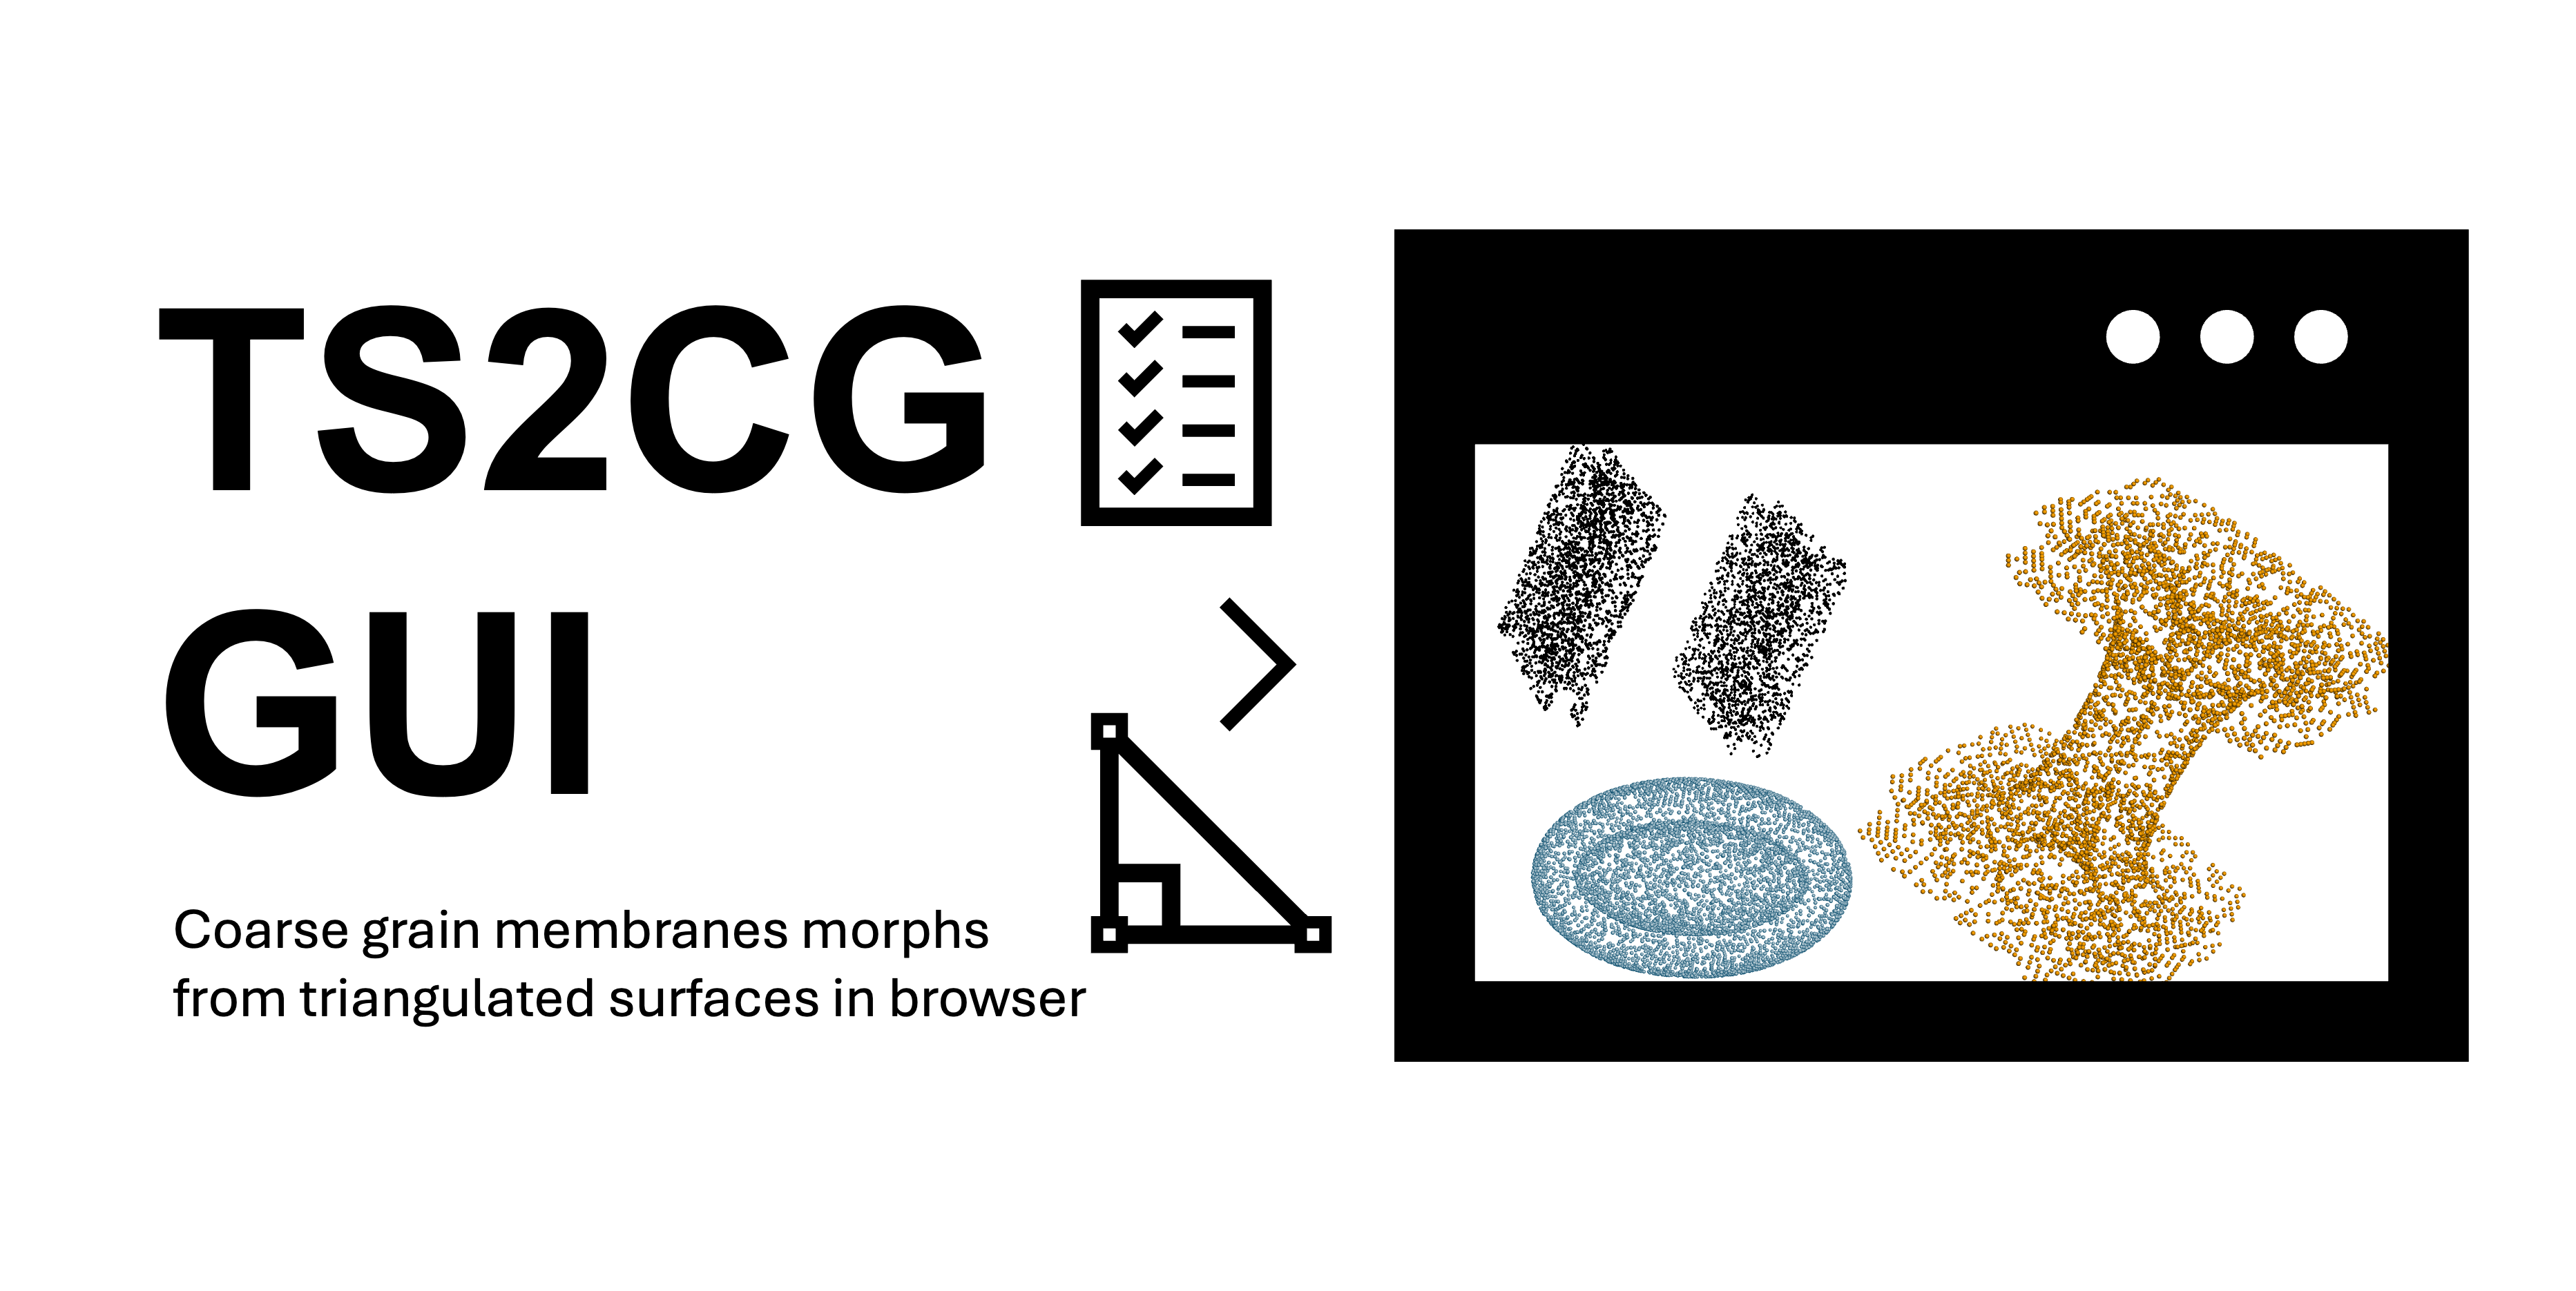


TS2CG - GUI uses existing pointilism transformations, as well as custom tsi morphing scripts and arrangements to allow for users to create their own membranes in browser to simulate and download. Change the height and width of tsi, to morph them into a shape of choosing, in a species of choice. TS2CG GUI also prepares the system for simulation within GROMACs.

In [ ]:
#@title Install dependencies
%%capture
import os
import sys
import requests
from google.colab import files
!pip install py3dmol
!apt-get update && apt-get upgrade -y && apt-get install -y gzip pymol dssp
import py3Dmol


os.chdir('/content/')
!git clone https://github.com/timnugent/memembed
%cd memembed
!make
!git clone https://github.com/MishterBluesky/PoreFormer.git
%cd PoreFormer
!make
%cd ../
%cd ../
!pip install pdb2pqr vermouth gromacswrapper==0.8.3 MDAnalysis wget
!git clone https://github.com/pstansfeld/cg2at
!wget https://github.com/pstansfeld/MemProtMD/raw/main/gromacs.zip
!wget https://github.com/pstansfeld/MemProtMD/raw/main/gromacs_d.zip
!wget https://github.com/pstansfeld/MemProtMD/raw/main/martini_v300.zip
!wget https://github.com/MishterBluesky/PoreFormer.git
!unzip -o martini_v300.zip
!unzip -o gromacs_d.zip
!unzip -o PoreFormer-main.zip
%mv /content/usr/local/gromacs/ /usr/local/
!ln -s /usr/local/gromacs/bin/gmx /usr/bin/gmx
!ln -s /usr/local/gromacs/bin/gmx_d /usr/bin/gmx_d
import gromacs
import MDAnalysis
import glob
import shutil
import subprocess
import wget
import pandas as pd
from gromacs import grompp, editconf, make_ndx, trjconv, pdb2gmx, mdrun , mdrun_d

In [ ]:
# @title Compile TS2CG
%%capture
%cd /content/memembed/PoreFormer
!chmod +x compile.sh
!./compile.sh



In [ ]:
#@title System parameters.
#@markdown Here you choose the area per lipid (lipid density), width % and the height of your system % as well as species
import math
from math import sqrt
import math
verbal_list = {
    "Vesicle -5nm Default": 'Sphere.tsi',
    "Two parallel membranes -20nm apart- 160nmsq": '3_Doublemembrane.tsi',
    "Pore -20nm deep -4nm pore": '3_Bigcare.tsi',
}
System = "Pore -20nm deep -4nm pore" #@param ["Pore -20nm deep -4nm pore", "Two parallel membranes -20nm apart- 160nmsq ", "Vesicle -5nm Default", "Sphere.tsi"]
tsi = verbal_list.get(System)
APL= "0.65" #@param {numerical} [0.63,0.65,0.67,0.70,0.65,0.60]
def scale_coordinates(input_file, output_file, scale_factor_x, scale_factor_y, scale_factor_z):
    with open(input_file, 'r') as infile:
        lines = infile.readlines()

    scaled_vertices = []
    stop_processing = False  # Flag to indicate whether to stop processing lines
    for line in lines:
        parts = line.split()
        if len(parts) > 1:
            if parts[0] == 'triangle':
                stop_processing = True  # Set flag to stop processing lines
            if not stop_processing:
                if parts[0] == 'box':
                    # Scale box dimensions
                    box_dimensions = [float(dim) for dim in parts[1:]]
                    scaled_box_dimensions = [
                        box_dimensions[0] * scale_factor_x,
                        box_dimensions[1] * scale_factor_y,
                        box_dimensions[2] * scale_factor_z
                    ]
                    scaled_box_line = f"box\t{scaled_box_dimensions[0]}\t{scaled_box_dimensions[1]}\t{scaled_box_dimensions[2]}\n"
                    scaled_vertices.append(scaled_box_line)
                elif parts[0].isdigit():  # Check if the line starts with a digit (indicating vertex coordinates)
                    vertex_id = int(parts[0])
                    x = float(parts[1]) * scale_factor_x
                    y = float(parts[2]) * scale_factor_y
                    z = float(parts[3]) * scale_factor_z
                    scaled_vertex = f"{vertex_id}\t{x}\t{y}\t{z}\n"
                    scaled_vertices.append(scaled_vertex)
                else:
                    scaled_vertices.append(line)  # If line does not start with 'box', 'vertex', or a digit, keep it unchanged
            else:
                scaled_vertices.append(line)  # Copy the line without scaling

    with open(output_file, 'w') as outfile:
        for vertex in scaled_vertices:
            outfile.write(vertex)

pore_size = 5 #@param  # New pore size in nm
original_pore_height = 20
pore_height = 20 #@param
original_pore_size = 4
# Calculate scaling factors
scale_factor_y = math.sqrt(pore_size / original_pore_size)
scale_factor_z = math.sqrt(pore_size / original_pore_size)  # Assuming z scaling is the same as x and y
scale_factor_x = math.sqrt(pore_height / original_pore_height)



# Scale the coordinates using the calculated scaling factor
scale_coordinates(tsi, "output.tsi", scale_factor_x, scale_factor_y, scale_factor_z)
tsi = "output.tsi"
Species = "Bacillus subtilis" #@param ["Escherichia coli", "Bacillus subtilis"]
if Species == "Bacillus subtilis":
      cardio = 0.10
      popg = 0.70
      pope = 0.20
else:
      cardio = 0.02
      popg = 0.20
      pope = 0.78

In [ ]:
#@title Create  System!
#@markdown Here 'TS2CG GUI/Poreformer' will make your system for you, using your input constraints. It effectively uses TS2CG as well as MDAnalysis and gromacs, to form a complete system ready for simulation.
%%capture
%cd /content/memembed/PoreFormer
!chmod +x APLbacGoogleColab.sh
!chmod +x APLbacGoogleColabbig.sh
!chmod +x topollipid.sh
if pore_size < 3 :
  !./APLbacGoogleColab.sh $APL $tsi $scale_factor_z $scale_factor_x $cardio $popg $pope
else:
  !./APLbacGoogleColabbig.sh $APL $tsi $scale_factor_z $scale_factor_x $cardio $popg $pope

In [ ]:
%%capture
#@markdown Install py3dmol visualisation software
!pip install py3dmol
!apt-get update && apt-get upgrade -y && apt-get install -y gzip pymol dssp
import os
import sys
import requests
import py3Dmol


In [ ]:
#@title Visualise   System
#@markdown Here you visualise your pore, **Orange beads representing phosphate headgroups**, unfortunately pore sizes larger than 6nm will crash google colab, so youll need to download output.pdb to visualise this, all other pores should be visible in browser.
working_dir = "/content/memembed/PoreFormer/"

APLFILE = f"7_Lipidx_{APL}.gro"
!echo $APL
!gmx editconf -f $APLFILE -o "output.pdb"

0.65
                     :-) GROMACS - gmx editconf, 2023.4 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content/memembed/PoreFormer
Command line:
  gmx editconf -f 7_Lipidx_0.65.gro -o output.pdb

Note that major changes are planned in future for editconf, to improve usability and utility.
Read 165390 atoms
Volume: 159990 nm^3, corresponds to roughly 71995600 electrons
No velocities found

GROMACS reminds you: "Erwin with his psi can do / Calculations quite a few. / But one thing has not been seen / Just what psi really mean." (Felix Bloch)



In [ ]:
#@title Count your molecules and prepare for simulation
#@markdown A little script will read your membrane system and count the POPG, CDL1 and POPE, itll then use this to make a topol.top file for simulation
APLFILE = f"7_Lipidx_{APL}.gro"
!echo $APL
!gmx editconf -f $APLFILE
!chmod +x topollipid.sh
!./topollipid.sh $APLFILE

0.65
                     :-) GROMACS - gmx editconf, 2023.4 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content/memembed/PoreFormer
Command line:
  gmx editconf -f 7_Lipidx_0.65.gro

Note that major changes are planned in future for editconf, to improve usability and utility.
Read 165390 atoms
Volume: 159990 nm^3, corresponds to roughly 71995600 electrons
No velocities found

GROMACS reminds you: "I Ripped the Cord Right Out Of the Phone" (Capt. Beefheart)

Okay lipid person, I am reading the .gro file you gave me and adding POPG to the topol file now


In [ ]:
#@title Prepare files for simulation
import os
from google.colab import files
# List of files to zip
files_to_zip = ['martini_v3.0.0.itp', 'martini_v3.0_CDLs.itp', 'martini_v3.0.0_ions_v1.itp', 'martini_v3.0.0_solvents_v1.itp', 'martini_v3.0.0_phospholipids_v1.itp','topol.top',f'{APLFILE}' ]

zip_file_name = f'Poreformer_{APL}_{pore_size}nm-pore_{pore_height}nm_layers.zip'

# Zip the files
os.system('zip -r {} {}'.format(zip_file_name, ' '.join(files_to_zip)))


In [ ]:
#@title Simulate! (for 2000 steps).. and download a tpr for a real simulation. (or to check it simulates with gmx_d)
!chmod +x AfterColab.sh
Simulate = f"./AfterColab.sh '{APL}' '{APL}'"
# Execute Sim
!{Simulate}

In [ ]:
#@title Download files for simulation
import os
from google.colab import files
APLFILE2 = f"11b_Lipid20_{APL}.gro"
# List of files to zip
files_to_zip = ['martini_v3.0.0.itp', 'martini_v3.0_CDLs.itp', 'martini_v3.0.0_ions_v1.itp', 'martini_v3.0.0_solvents_v1.itp', 'martini_v3.0.0_phospholipids_v1.itp','topol.top',f'{APLFILE2}' ]

zip_file_name = f'Sim_Poreformer_{APL}_{pore_size}nm-pore_{pore_height}nm_layers.zip'

# Zip the files
os.system('zip -r {} {}'.format(zip_file_name, ' '.join(files_to_zip)))

# Download the zip file
files.download(zip_file_name)